In [1]:
import sys
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)


Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]
Pandas version: 2.3.3
Matplotlib version: 3.10.6


Combining Datasets

In [3]:
import os
print(os.getcwd())

/Users/peggy/Documents/Si-MaterialsProject/notebooks


In [4]:
import os
print(os.listdir())

['01_combine_datasets.ipynb', '.ipynb_checkpoints']


In [5]:
print(os.listdir(".."))

['.DS_Store', '.ipynb_checkpoints', 'data', 'notebooks']


In [6]:

files = [
    "../data/raw/Si.csv",
    "../data/raw/Si-O.csv",
    "../data/raw/Si-C.csv",
    "../data/raw/Si-N.csv"
]

dfs = [pd.read_csv(f) for f in files]
df = pd.concat(dfs, ignore_index=True).drop_duplicates()

print(df.shape)
print(df.columns)


(438, 33)
Index(['Unnamed: 0', 'Synthesizable', 'Material ID', 'Formula',
       'Crystal System', 'Space Group Symbol', 'Space Group Number', 'Sites',
       'Energy Above Hull', 'Formation Energy', 'Predicted Stable', 'Volume',
       'Density', 'Band Gap', 'Is Gap Direct', 'Is Metal', 'Magnetic Ordering',
       'Total Magnetization', 'Bulk Modulus, Voigt', 'Bulk Modulus, Reuss',
       'Bulk Modulus, VRH', 'Shear Modulus, Voigt', 'Shear Modulus, Reuss',
       'Shear Modulus, VRH', 'Elastic Anisotropy', 'Weighted Surface Energy',
       'Surface Anisotropy', 'Shape Factor', 'Work Function',
       'Piezoelectric Modulus', 'Total Dielectric Constant',
       'Ionic Dielectric Constant', 'Static Dielectric Constant'],
      dtype='object')


Feature Engineering 

In [7]:
from collections import Counter  # Import the Counter class
import re  # Also import re since it's used for regex pattern matching

def calc_fractions(formula):
    if pd.isna(formula):
        return {}
    
    counts = Counter()
    pattern = r'([A-Z][a-z]?)(\d*)'
    
    for el, num in re.findall(pattern, str(formula)):
        counts[el] += int(num) if num else 1
    
    total = sum(counts.values())
    
    if total == 0:
        return {}
    
    return {el + "_frac": c / total for el, c in counts.items()}


# Apply safely
frac_df = df["Formula"].apply(calc_fractions)
frac_df = pd.DataFrame(list(frac_df)).fillna(0)

df_features = pd.concat([df, frac_df], axis=1)

print(df_features.head())
print(df_features.columns)

   Unnamed: 0  Synthesizable Material ID Formula Crystal System  \
0           0           True  mp-1244933      Si      Triclinic   
1           1           True  mp-1120447      Si      Triclinic   
2           2           True  mp-1244971      Si      Triclinic   
3           3           True  mp-1244990      Si      Triclinic   
4           4           True  mp-1245242      Si      Triclinic   

  Space Group Symbol  Space Group Number  Sites  Energy Above Hull  \
0                 P1                   1    100           0.349291   
1                 P1                   1      8           0.372510   
2                 P1                   1    100           0.316752   
3                 P1                   1    100           0.366274   
4                 P1                   1    100           0.316910   

   Formation Energy  ...  Shape Factor  Work Function  Piezoelectric Modulus  \
0          0.349291  ...           NaN            NaN                    NaN   
1          0.372

BASIC EDA

Band Gap Distribution 

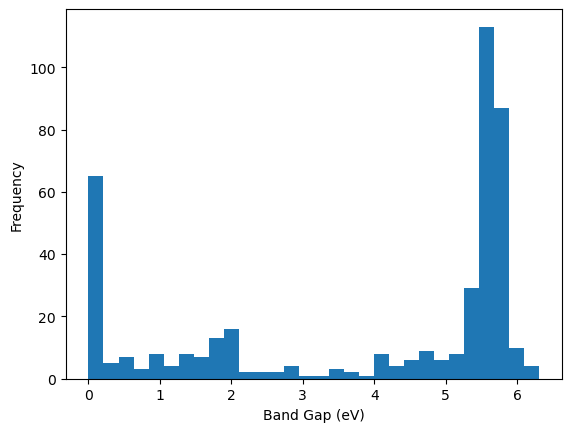

In [6]:
plt.hist(df_features["Band Gap"],bins=30)
plt.xlabel("Band Gap (eV)")
plt.ylabel("Frequency")
plt.show()


Band Gap vs Oxygen fraction

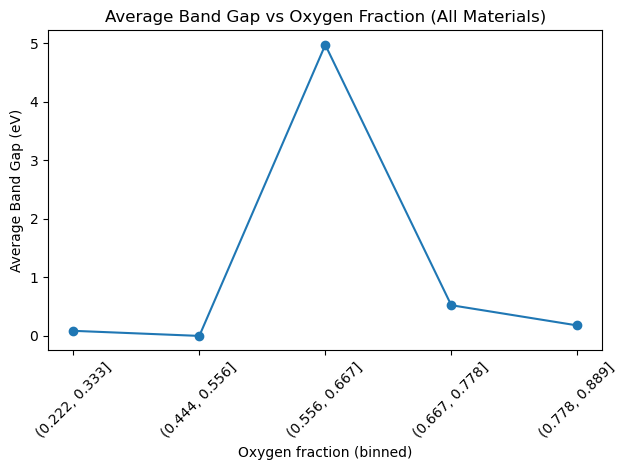

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use all materials
df_plot = df_features.copy()

# Standard bins
bins = np.linspace(0, 1, 10)

# Bin oxygen fraction
df_plot['O_bin'] = pd.cut(df_plot['O_frac'], bins)

# Compute mean band gap per bin
bg_o = df_plot.groupby('O_bin', observed=True)['Band Gap'].mean()

# Plot
plt.figure()
plt.plot(bg_o.index.astype(str), bg_o.values, marker='o')
plt.xticks(rotation=45)
plt.xlabel("Oxygen fraction (binned)")
plt.ylabel("Average Band Gap (eV)")
plt.title("Average Band Gap vs Oxygen Fraction (All Materials)")
plt.tight_layout()
plt.show()


In [27]:
stats = df_plot.groupby("O_bin", observed=True)["Band Gap"].agg(["mean", "std", "count"])
print(stats)

                    mean       std  count
O_bin                                    
(0.222, 0.333]  0.086925  0.101083      4
(0.444, 0.556]  0.000000       NaN      1
(0.556, 0.667]  4.971551  1.519000    324
(0.667, 0.778]  0.524591  1.033985     11
(0.778, 0.889]  0.179200  0.196420      3


Band Gap vs Silicon fraction

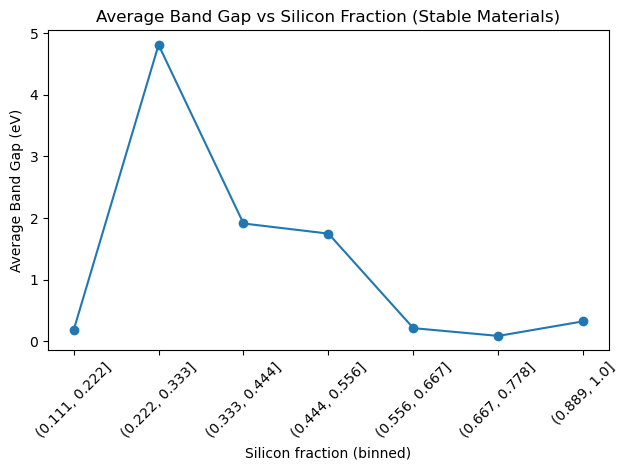

In [8]:
df_plot['Si_bin'] = pd.cut(df_plot['Si_frac'], bins)

bg_si = df_plot.groupby('Si_bin', observed=True)['Band Gap'].mean()

plt.figure()
plt.plot(bg_si.index.astype(str), bg_si.values, marker='o')
plt.xticks(rotation=45)
plt.xlabel("Silicon fraction (binned)")
plt.ylabel("Average Band Gap (eV)")
plt.title("Average Band Gap vs Silicon Fraction (Stable Materials)")
plt.tight_layout()
plt.show()

Correlation Heatmap

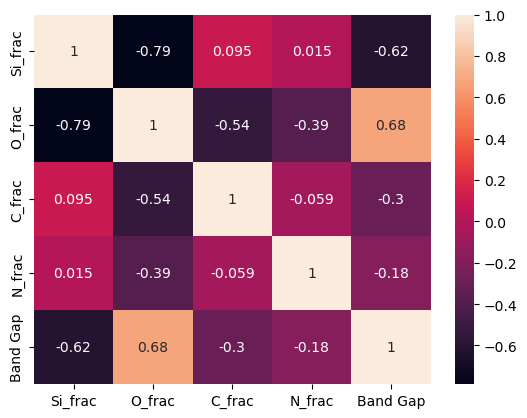

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
features = ["Si_frac", "O_frac", "C_frac", "N_frac"]
sns.heatmap(df_features[features + ["Band Gap"]].corr(), annot=True)
plt.show()


Si fraction vs Band Gap

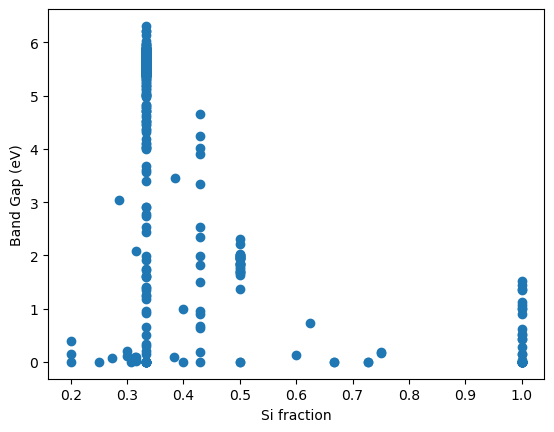

In [11]:
plt.scatter(df_features["Si_frac"], df_features["Band Gap"])
plt.xlabel("Si fraction")
plt.ylabel("Band Gap (eV)")
plt.show()


Stability Filter

In [12]:
df_stable = df_features[df_features["Energy Above Hull"] <= 0.05]

print("Total materials:", len(df_features))
print("Stable materials:", len(df_stable))


Total materials: 438
Stable materials: 236


Stability vs Band Gap Plot

Composition Effect

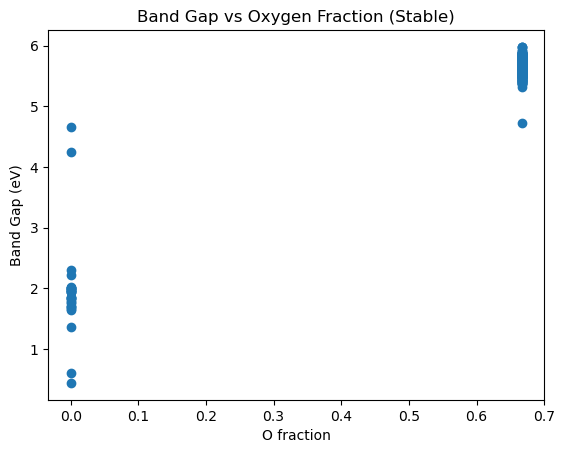

In [13]:
plt.scatter(df_stable["O_frac"], df_stable["Band Gap"])
plt.xlabel("O fraction")
plt.ylabel("Band Gap (eV)")
plt.title("Band Gap vs Oxygen Fraction (Stable)")
plt.show()


In [14]:
df_sio = df_features[
    (df_features["Si_frac"] > 0) &
    (df_features["O_frac"] > 0) &
    (df_features["C_frac"] == 0) &
    (df_features["N_frac"] == 0)
].copy()

print("Total Si–O compounds:", len(df_sio))


Total Si–O compounds: 343


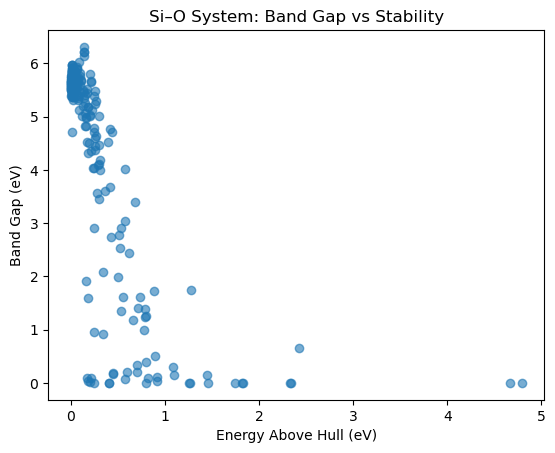

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_sio["Energy Above Hull"], df_sio["Band Gap"], alpha=0.6)
plt.xlabel("Energy Above Hull (eV)")
plt.ylabel("Band Gap (eV)")
plt.title("Si–O System: Band Gap vs Stability")
plt.show()


Inference: Most stable compounds have band gaps between 4-6 (approx). Which also supports the fact that it is a Si-O system. 

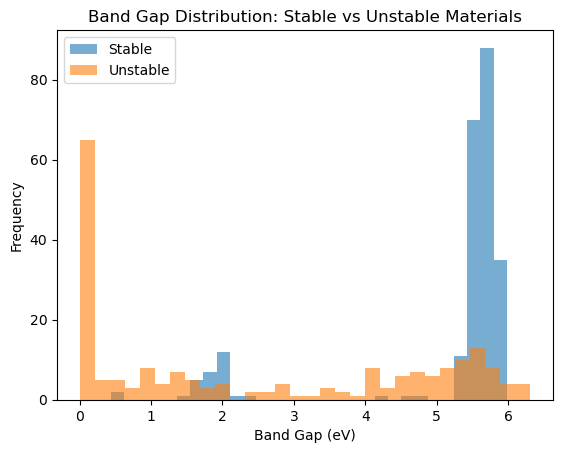

Stable mean band gap: 5.161011440677966
Unstable mean band gap: 2.4683940594059406


In [16]:
df_stable = df_features[df_features["Energy Above Hull"] <= 0.05]
df_unstable = df_features[df_features["Energy Above Hull"] > 0.05]

plt.figure()

plt.hist(df_stable["Band Gap"], bins=30, alpha=0.6, label="Stable")
plt.hist(df_unstable["Band Gap"], bins=30, alpha=0.6, label="Unstable")

plt.xlabel("Band Gap (eV)")
plt.ylabel("Frequency")
plt.title("Band Gap Distribution: Stable vs Unstable Materials")
plt.legend()
plt.show()

print("Stable mean band gap:", df_stable["Band Gap"].mean())
print("Unstable mean band gap:", df_unstable["Band Gap"].mean())



Inference: Band gap alone does not guarantee stability.

But stable materials tend to cluster in specific regions.

In [17]:
# Si–O system
df_sio = df_features[
    (df_features["Si_frac"] > 0) &
    (df_features["O_frac"] > 0) &
    (df_features["C_frac"] == 0) &
    (df_features["N_frac"] == 0)
].copy()

# Si–C system
df_sic = df_features[
    (df_features["Si_frac"] > 0) &
    (df_features["C_frac"] > 0) &
    (df_features["O_frac"] == 0) &
    (df_features["N_frac"] == 0)
].copy()

# Si–N system
df_sin = df_features[
    (df_features["Si_frac"] > 0) &
    (df_features["N_frac"] > 0) &
    (df_features["O_frac"] == 0) &
    (df_features["C_frac"] == 0)
].copy()

print("Si–O count:", len(df_sio))
print("Si–C count:", len(df_sic))
print("Si–N count:", len(df_sin))


Si–O count: 343
Si–C count: 34
Si–N count: 18


In [18]:
print("Si–O mean band gap:", df_sio["Band Gap"].mean())
print("Si–C mean band gap:", df_sic["Band Gap"].mean())
print("Si–N mean band gap:", df_sin["Band Gap"].mean())


Si–O mean band gap: 4.715563265306122
Si–C mean band gap: 1.512370588235294
Si–N mean band gap: 1.879511111111111


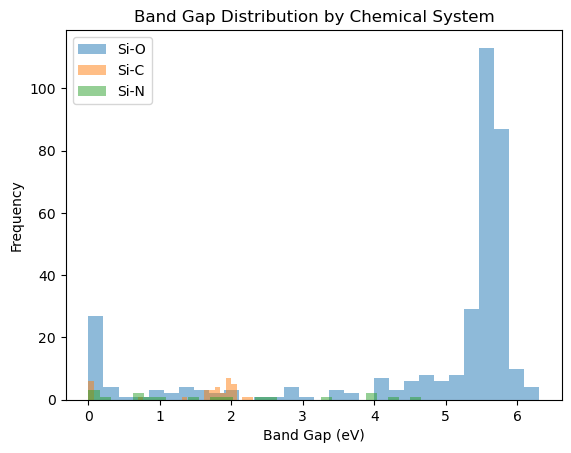

In [19]:
plt.hist(df_sio["Band Gap"], bins=30, alpha=0.5, label="Si-O")
plt.hist(df_sic["Band Gap"], bins=30, alpha=0.5, label="Si-C")
plt.hist(df_sin["Band Gap"], bins=30, alpha=0.5, label="Si-N")

plt.xlabel("Band Gap (eV)")
plt.ylabel("Frequency")
plt.legend()
plt.title("Band Gap Distribution by Chemical System")
plt.show()


In [20]:
# Count how many unique band gap values exist per formula
variation = df_features.groupby("Formula")["Band Gap"].nunique()

# Show formulas where band gap varies
variation[variation > 1].head()


Formula
Si        20
Si3N4     16
Si3O       2
Si3O7      2
Si6O13     4
Name: Band Gap, dtype: int64

In [21]:
y = df_features["Band Gap"]

In [22]:
X = df_features[["Si_frac", "O_frac", "C_frac", "N_frac"]]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

r2 = model.score(X_test, y_test)
print("R²:", r2)

R²: 0.511769067256884


In [25]:
import pandas as pd

coefficients = pd.Series(model.coef_, index=X.columns)
print(coefficients)

Si_frac   -2.989472
O_frac     3.713553
C_frac    -0.611267
N_frac    -0.112814
dtype: float64
